# Berlin Bike-Sharing — Exploratory Data Analysis

This notebook covers:
1. Load all raw parquet files
2. Data quality checks
3. Demand calculation (snapshot changes → daily rentals)
4. Station assignment to Berlin Bezirke (12 districts)
5. Demand patterns by district
6. Weather data (Open-Meteo)
7. Feature engineering preview
8. Save processed data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import plotly.express as px

import geopandas as gpd
import holidays

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
DATA_DIR = Path('../bike_data_berlin')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TIMEZONE = 'Europe/Berlin'
SYSTEMS = ['nextbike-berlin', 'callabike-berlin']

BEZIRKE_PATH = Path('../configs/berlin_bezirke.geojson')

## 1. Load Data

In [3]:
files = sorted(DATA_DIR.glob('*.parquet'))
print(f'Found {len(files)} parquet files')

dfs = []
for f in files:
    df = pd.read_parquet(f)
    df['source_file'] = f.name
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
# Keep only the two main systems
raw = raw[raw['tag'].isin(SYSTEMS)].copy()

print(f'\nTotal rows (main systems): {len(raw):,}')
print(f'Date range: {raw["timestamp"].min().date()} → {raw["timestamp"].max().date()}')
print(f'\n{raw.dtypes}')

Found 39 parquet files

Total rows (main systems): 7,064,925
Date range: 2025-01-01 → 2026-04-30

tag                       str
id                        str
nuid                      str
name                      str
latitude              float64
longitude             float64
bikes                   int32
free                  float64
extra                  object
timestamp      datetime64[us]
source_file               str
dtype: object


In [4]:
# Per-file summary
summary = []
for df in dfs:
    tag = df['tag'].iloc[0]
    if tag not in SYSTEMS:
        continue
    summary.append({
        'file': df['source_file'].iloc[0],
        'system': tag,
        'rows': len(df),
        'stations': df['nuid'].nunique(),
        'start': df['timestamp'].min().date(),
        'end': df['timestamp'].max().date(),
    })

pd.DataFrame(summary).set_index('file')

,system,rows,stations,start,end
file,,,,,
202501-callabike-berlin-stats.parquet,callabike-berlin,28886,474,2025-01-01,2025-01-31
202501-nextbike-berlin-stats.parquet,nextbike-berlin,394074,4585,2025-01-01,2025-01-31
202502-callabike-berlin-stats.parquet,callabike-berlin,31789,488,2025-02-01,2025-02-28
202502-nextbike-berlin-stats.parquet,nextbike-berlin,416185,4587,2025-02-01,2025-02-28
202503-callabike-berlin-stats.parquet,callabike-berlin,40031,1044,2025-03-01,2025-03-31
202503-nextbike-berlin-stats.parquet,nextbike-berlin,600617,4587,2025-03-01,2025-03-31
202504-callabike-berlin-stats.parquet,callabike-berlin,34310,556,2025-04-01,2025-04-30
202504-nextbike-berlin-stats.parquet,nextbike-berlin,654179,4464,2025-04-01,2025-04-30
202505-callabike-berlin-stats.parquet,callabike-berlin,29552,490,2025-05-01,2025-05-31


## 2. Data Quality

In [5]:
print('=== NULL VALUES ===')
print(raw.isnull().sum())

print('\n=== BIKES COLUMN ===')
print(raw['bikes'].describe())
print(f'  negative bikes:  {(raw["bikes"] < 0).sum():,}')
print(f'  bikes == 0:      {(raw["bikes"] == 0).mean()*100:.1f}% of rows')
print(f'  bikes > 50:      {(raw["bikes"] > 50).sum():,}')

print('\n=== FREE (SLOTS) COLUMN ===')
print(raw['free'].describe())

=== NULL VALUES ===
tag                 0
id                  0
nuid                0
name                0
latitude            0
longitude           0
bikes               0
free           171608
extra               0
timestamp           0
source_file         0
dtype: int64

=== BIKES COLUMN ===
count   7064925.00
mean          2.71
std           3.54
min           0.00
25%           1.00
50%           2.00
75%           3.00
max          99.00
Name: bikes, dtype: float64
  negative bikes:  0
  bikes == 0:      18.7% of rows
  bikes > 50:      2,829

=== FREE (SLOTS) COLUMN ===
count   6893317.00
mean          5.36
std           7.72
min           0.00
25%           2.00
50%           3.00
75%           5.00
max          40.00
Name: free, dtype: float64


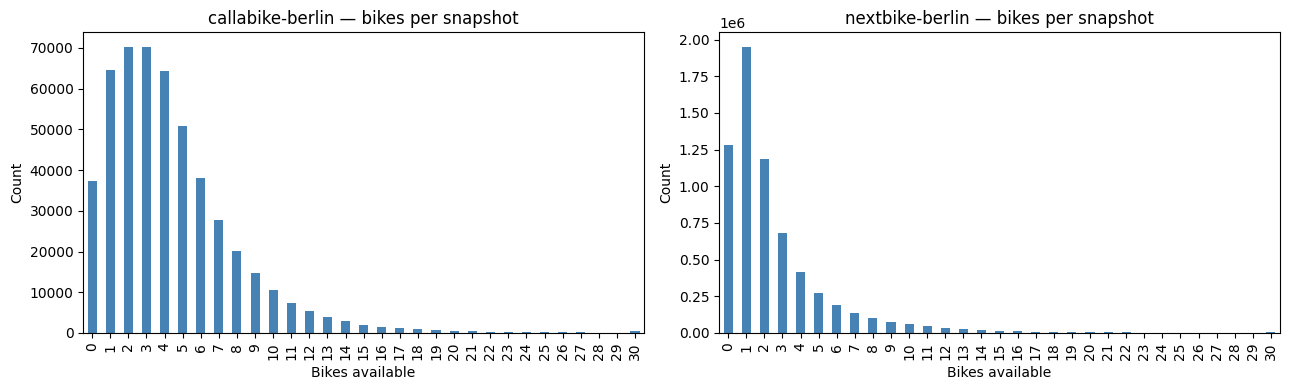

In [6]:
# Distribution of bikes available, by system
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (tag, grp) in zip(axes, raw.groupby('tag')):
    grp['bikes'].clip(0, 30).value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{tag} — bikes per snapshot')
    ax.set_xlabel('Bikes available')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
# Snapshot frequency: how often are stations observed?
print('Snapshot interval (minutes) per system:')
for tag, grp in raw.groupby('tag'):
    grp_sorted = grp.sort_values(['nuid', 'timestamp'])
    gaps = grp_sorted.groupby('nuid')['timestamp'].diff().dt.total_seconds().div(60).dropna()
    gaps = gaps[gaps > 0]
    print(f'\n  {tag}')
    print(f'    median: {gaps.median():.1f} min')
    print(f'    p95:    {gaps.quantile(0.95):.1f} min')
    print(f'    p99:    {gaps.quantile(0.99):.1f} min')
    print(f'    max:    {gaps.max():.1f} min')

Snapshot interval (minutes) per system:

  callabike-berlin
    median: 373.3 min
    p95:    2613.3 min
    p99:    5529.8 min
    max:    516187.1 min

  nextbike-berlin
    median: 56.9 min
    p95:    1164.0 min
    p99:    3971.0 min
    max:    525740.4 min


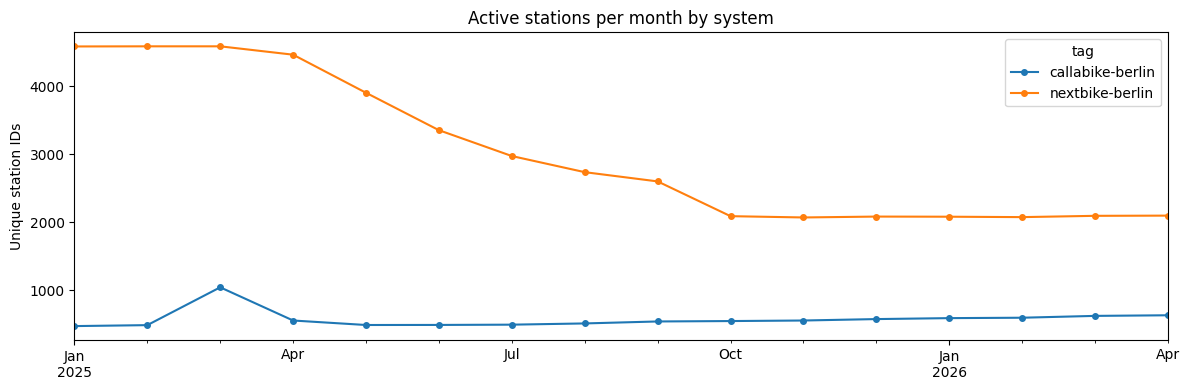

tag      callabike-berlin  nextbike-berlin
month                                     
2025-01               474             4585
2025-02               488             4587
2025-03              1044             4587
2025-04               556             4464
2025-05               490             3904
2025-06               491             3354
2025-07               495             2974
2025-08               513             2737
2025-09               542             2601
2025-10               548             2090
2025-11               556             2071
2025-12               577             2084
2026-01               591             2082
2026-02               597             2076
2026-03               624             2095
2026-04               633             2098


In [8]:
# Station count over time, detect network shrinkage
raw['month'] = raw['timestamp'].dt.to_period('M')
station_counts = raw.groupby(['month', 'tag'])['nuid'].nunique().unstack('tag')

station_counts.plot(figsize=(12, 4), marker='o', markersize=4)
plt.title('Active stations per month by system')
plt.ylabel('Unique station IDs')
plt.xlabel('')
plt.tight_layout()
plt.show()

print(station_counts.to_string())

## 3. Demand Calculation

The raw data contains **snapshots** of each station: bikes available at a point in time.  
We estimate **rentals** as the sum of all decreases in `bikes` count within a calendar day, per station.

**Definition:** `demand = Σ max(0, bikes_prev - bikes_curr)` for all consecutive snapshots on the same calendar day.

Key decisions:
- Only transitions **within the same day** are used.
- Positive changes (bikes added) are ignored, as they represent returns or rebalancing.
- No gap threshold is applied: the snapshot intervals are too long to justify one (nextbike median ~57 min, callabike median ~6 hours), and at daily aggregation level it would discard most valid transitions.
- At the **district level**, rebalancing within a district cancels out (a bike moved between two stations in the same district does not affect the district total).

In [9]:
def compute_daily_demand(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['nuid', 'timestamp']).copy()
    df['date'] = df['timestamp'].dt.tz_localize('UTC').dt.tz_convert(TIMEZONE).dt.date

    grp = df.groupby(['nuid', 'date'])
    df['prev_bikes'] = grp['bikes'].shift(1)

    # Rentals = decrease in bikes; only within the same station×day group
    df['rentals'] = (df['prev_bikes'] - df['bikes']).clip(lower=0).fillna(0)

    daily = (
        df.groupby(['nuid', 'name', 'latitude', 'longitude', 'date'])
        .agg(rentals=('rentals', 'sum'), snapshots=('bikes', 'count'))
        .reset_index()
    )
    return daily


nextbike_raw = raw[raw['tag'] == 'nextbike-berlin']
callabike_raw = raw[raw['tag'] == 'callabike-berlin']

print('Computing daily demand for nextbike-berlin...')
demand_nb = compute_daily_demand(nextbike_raw)
print(f'  {len(demand_nb):,} station×day records')

print('Computing daily demand for callabike-berlin...')
demand_cb = compute_daily_demand(callabike_raw)
print(f'  {len(demand_cb):,} station×day records')

Computing daily demand for nextbike-berlin...
  959,140 station×day records
Computing daily demand for callabike-berlin...
  189,597 station×day records


In [10]:
# Rentals per station per day — sanity check
print('Nextbike rentals/station/day:')
print(demand_nb['rentals'].describe())

print('\nCallabike rentals/station/day:')
print(demand_cb['rentals'].describe())

# Stations with suspiciously high daily rentals (potential rebalancing leakage)
threshold = 50
high = demand_nb[demand_nb['rentals'] > threshold]
print(f'\nNextbike station-days with > {threshold} estimated rentals: {len(high):,}')
print(high.nlargest(10, 'rentals')[['name', 'date', 'rentals', 'snapshots']])

Nextbike rentals/station/day:
count   959140.00
mean         3.29
std          4.58
min          0.00
25%          1.00
50%          2.00
75%          4.00
max        108.00
Name: rentals, dtype: float64

Callabike rentals/station/day:
count   189597.00
mean         1.03
std          1.88
min          0.00
25%          0.00
50%          0.00
75%          1.00
max         47.00
Name: rentals, dtype: float64

Nextbike station-days with > 50 estimated rentals: 361
                                                     name        date  \
590009               Jelbi Graefestraße/Planufer (KRE/GP)  2026-02-28   
894334                                 Seestraße/Nordufer  2025-07-02   
359340  virtuell - Tiergarten (Hofjägerallee/Tiergarte...  2025-01-30   
278579           virtuell - Hannoversche Straße (HU Nord)  2025-01-27   
720731  S+U Hermannstraße | BONUS-Station: Return(Rück...  2025-02-20   
613862  S+U Hauptbahnhof/Europaplatz West | BONUS-Stat...  2025-02-10   
613899  S+U Hauptbahnho

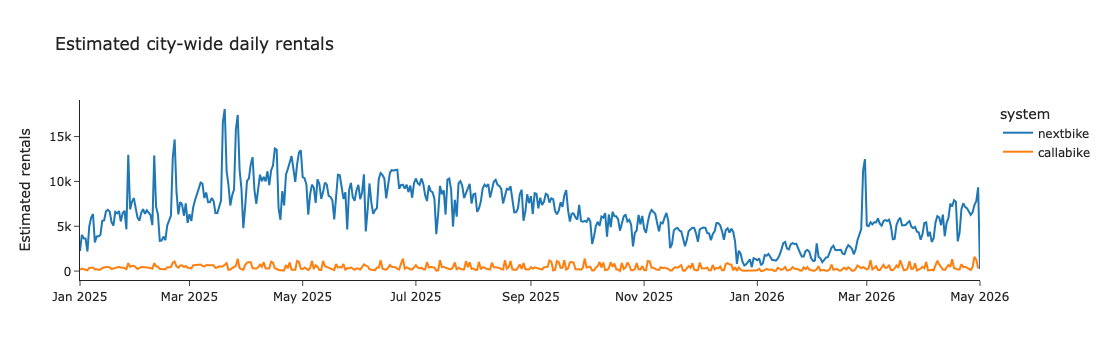

In [11]:
# City-wide daily demand
def city_daily(demand_df, label):
    d = demand_df.groupby('date')['rentals'].sum().reset_index()
    d['date'] = pd.to_datetime(d['date'])
    d['system'] = label
    return d

city = pd.concat([
    city_daily(demand_nb, 'nextbike'),
    city_daily(demand_cb, 'callabike'),
])

fig = px.line(
    city, x='date', y='rentals', color='system',
    title='Estimated city-wide daily rentals',
    labels={'rentals': 'Estimated rentals', 'date': ''},
    template='simple_white'
)
fig.show()

In [12]:
# Combined city-wide demand (both systems)
city_combined = (
    city.groupby('date')['rentals'].sum()
    .reset_index()
    .rename(columns={'rentals': 'total_rentals'})
)
city_combined['date'] = pd.to_datetime(city_combined['date'])
city_combined['dow'] = city_combined['date'].dt.day_name()

print(f'Days in dataset: {len(city_combined)}')
print(f'\nTotal rentals stats:')
print(city_combined['total_rentals'].describe())

Days in dataset: 486

Total rentals stats:
count     486.00
mean     6894.41
std      3165.44
min       229.00
25%      4884.50
50%      6735.00
75%      9151.25
max     18777.00
Name: total_rentals, dtype: float64


## 4. Station Assignment to Berlin Bezirke (12 Districts)

In [13]:
# Load Berlin Bezirke boundaries from local file
bezirke = gpd.read_file(BEZIRKE_PATH)
print('Columns:', bezirke.columns.tolist())
print('\nDistricts:')
print(bezirke['name'].tolist())

Columns: ['name', 'description', 'cartodb_id', 'created_at', 'updated_at', 'geometry']

Districts:
['Mitte', 'Friedrichshain-Kreuzberg', 'Pankow', 'Charlottenburg-Wilmersdorf', 'Spandau', 'Steglitz-Zehlendorf', 'Tempelhof-Schöneberg', 'Neukölln', 'Treptow-Köpenick', 'Marzahn-Hellersdorf', 'Lichtenberg', 'Reinickendorf']


In [14]:
bezirke = bezirke[['name', 'geometry']].rename(columns={'name': 'district'})
# CRS: Coordinate Reference System, PSG:4326 is the standard GPS system
bezirke = bezirke.to_crs('EPSG:4326')
print(bezirke['district'].tolist())

['Mitte', 'Friedrichshain-Kreuzberg', 'Pankow', 'Charlottenburg-Wilmersdorf', 'Spandau', 'Steglitz-Zehlendorf', 'Tempelhof-Schöneberg', 'Neukölln', 'Treptow-Köpenick', 'Marzahn-Hellersdorf', 'Lichtenberg', 'Reinickendorf']


In [15]:
# Get all unique stations across both systems
stations = pd.concat([
    demand_nb[['nuid', 'name', 'latitude', 'longitude']],
    demand_cb[['nuid', 'name', 'latitude', 'longitude']],
]).drop_duplicates('nuid').dropna(subset=['latitude', 'longitude'])

stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations['longitude'], stations['latitude']),
    crs='EPSG:4326'
)

# Spatial join: assign each station to a Bezirk
stations_joined = gpd.sjoin(stations_gdf, bezirke, how='left', predicate='within')
stations_joined = stations_joined[['nuid', 'district']].drop_duplicates('nuid')

n_matched = stations_joined['district'].notna().sum()
n_total = len(stations_joined)
print(f'Stations matched to a district: {n_matched:,} / {n_total:,} ({n_matched/n_total*100:.1f}%)')
print(f'Unmatched (outside Berlin polygons): {n_total - n_matched:,}')
print(f'\nStations per district:')
print(stations_joined['district'].value_counts().to_string())

Stations matched to a district: 5,848 / 5,860 (99.8%)
Unmatched (outside Berlin polygons): 12

Stations per district:
district
Mitte                         1254
Friedrichshain-Kreuzberg       930
Charlottenburg-Wilmersdorf     775
Tempelhof-Schöneberg           492
Pankow                         482
Treptow-Köpenick               457
Lichtenberg                    375
Neukölln                       367
Steglitz-Zehlendorf            235
Marzahn-Hellersdorf            220
Spandau                        156
Reinickendorf                  105


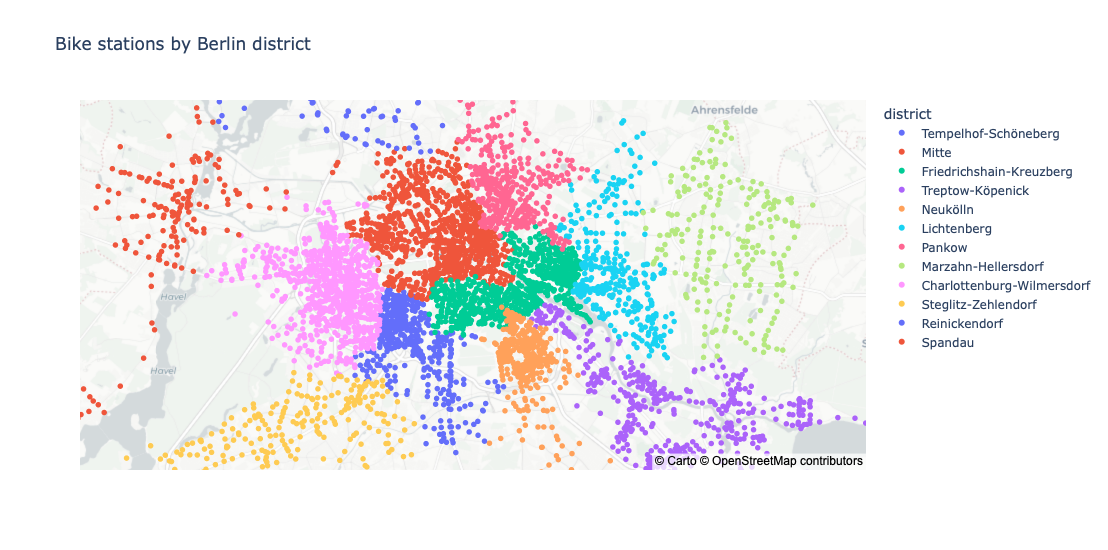

In [16]:
# Map: stations coloured by district
stations_vis = stations.merge(stations_joined, on='nuid', how='left')

fig = px.scatter_mapbox(
    stations_vis.dropna(subset=['district']),
    lat='latitude', lon='longitude',
    color='district',
    hover_name='name',
    zoom=10, height=550,
    title='Bike stations by Berlin district',
    mapbox_style='carto-positron'
)
fig.show()

## 5. Demand by District

In [17]:
# Merge station→district into demand data, aggregate by district×day
demand_all = pd.concat([
    demand_nb.assign(system='nextbike'),
    demand_cb.assign(system='callabike'),
])

demand_all = demand_all.merge(stations_joined, on='nuid', how='left')
demand_all['date'] = pd.to_datetime(demand_all['date'])

district_daily = (
    demand_all.dropna(subset=['district'])
    .groupby(['date', 'district'])['rentals']
    .sum()
    .reset_index()
)

print(f'District×day records: {len(district_daily):,}')
print(f'\nRentals per district-day:')
print(district_daily.groupby('district')['rentals'].describe().round(1).to_string())

District×day records: 5,783

Rentals per district-day:
                            count    mean    std   min     25%     50%     75%     max
district                                                                              
Charlottenburg-Wilmersdorf 486.00  586.70 349.30  4.00  331.50  523.00  802.80 1947.00
Friedrichshain-Kreuzberg   486.00 1762.80 779.80 94.00 1266.20 1715.50 2290.00 4380.00
Lichtenberg                486.00  399.70 163.00 23.00  277.00  405.00  529.00  880.00
Marzahn-Hellersdorf        475.00    9.70  14.60  0.00    1.00    4.00   12.00  134.00
Mitte                      486.00 2078.30 946.30 33.00 1498.80 2076.00 2667.00 5747.00
Neukölln                   486.00  665.00 315.30 25.00  453.80  645.50  899.80 1731.00
Pankow                     486.00  521.30 274.20 10.00  320.20  491.50  715.80 1710.00
Reinickendorf              486.00   18.30  13.10  0.00   10.00   16.00   25.00  113.00
Spandau                    448.00   11.10  15.70  0.00    1.00    7.00   17

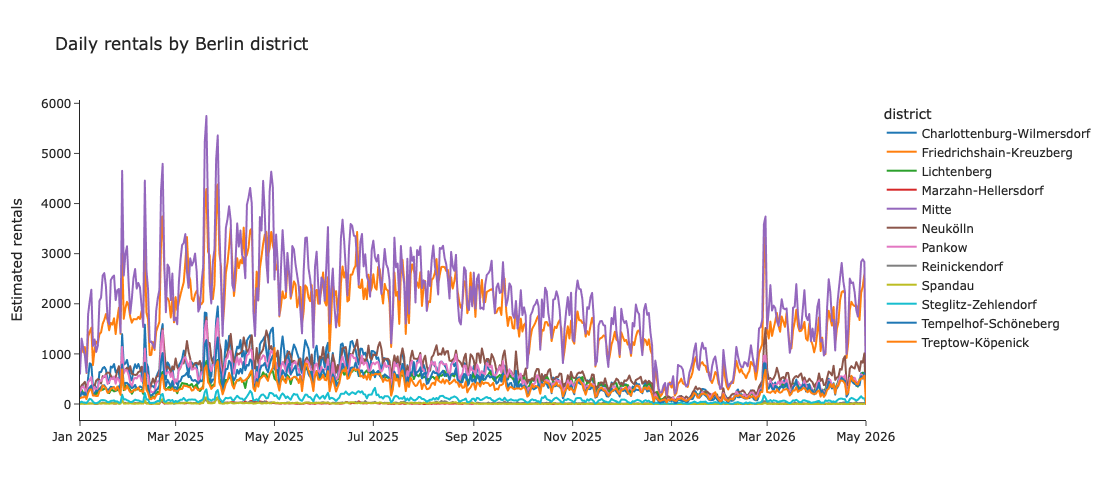

In [18]:
# Time series: daily demand per district
fig = px.line(
    district_daily,
    x='date', y='rentals', color='district',
    title='Daily rentals by Berlin district',
    labels={'rentals': 'Estimated rentals', 'date': ''},
    template='simple_white',
    height=500
)
fig.show()

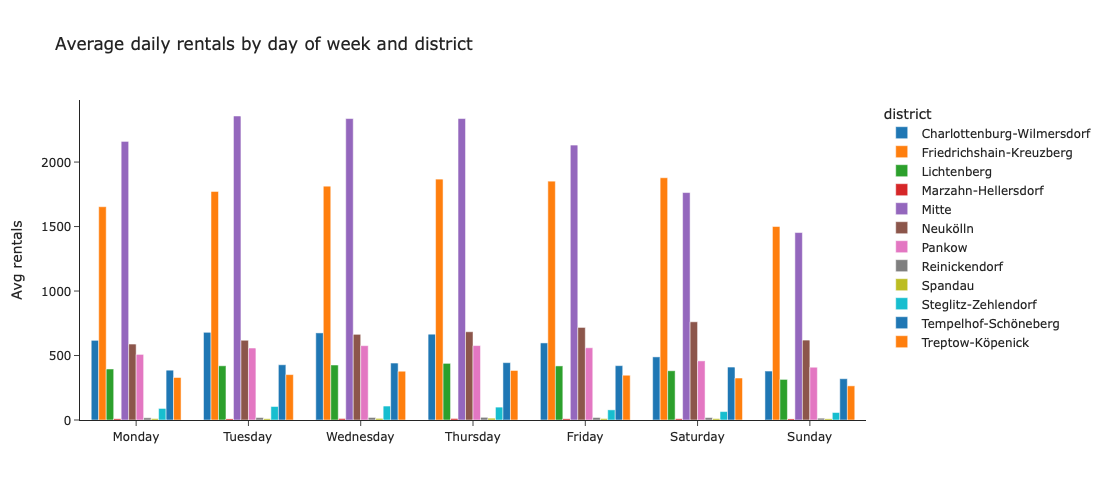

In [19]:
# Average rentals by day-of-week per district
district_daily['dow'] = district_daily['date'].dt.dayofweek  # 0=Monday
district_daily['dow_name'] = district_daily['date'].dt.day_name()

dow_avg = (
    district_daily.groupby(['district', 'dow', 'dow_name'])['rentals']
    .mean()
    .reset_index()
    .sort_values(['district', 'dow'])
)

fig = px.bar(
    dow_avg,
    x='dow_name', y='rentals', color='district',
    barmode='group',
    category_orders={'dow_name': ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']},
    title='Average daily rentals by day of week and district',
    labels={'rentals': 'Avg rentals', 'dow_name': ''},
    template='simple_white',
    height=500
)
fig.show()

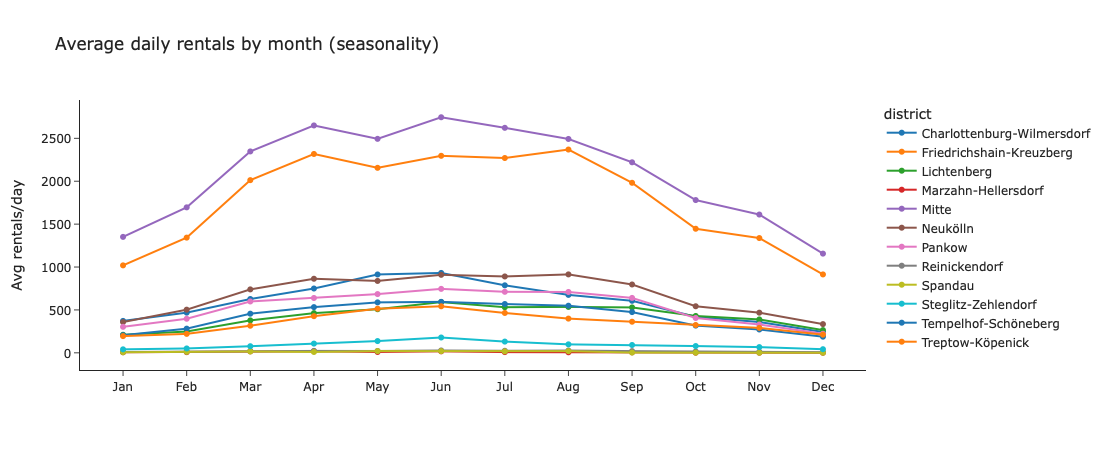

In [20]:
# Monthly demand profile: seasonality check
district_daily['month'] = district_daily['date'].dt.month
district_daily['month_name'] = district_daily['date'].dt.strftime('%b')

month_avg = (
    district_daily.groupby(['district', 'month', 'month_name'])['rentals']
    .mean()
    .reset_index()
    .sort_values(['district', 'month'])
)

fig = px.line(
    month_avg,
    x='month_name', y='rentals', color='district',
    markers=True,
    category_orders={'month_name': ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']},
    title='Average daily rentals by month (seasonality)',
    labels={'rentals': 'Avg rentals/day', 'month_name': ''},
    template='simple_white',
    height=450
)
fig.show()

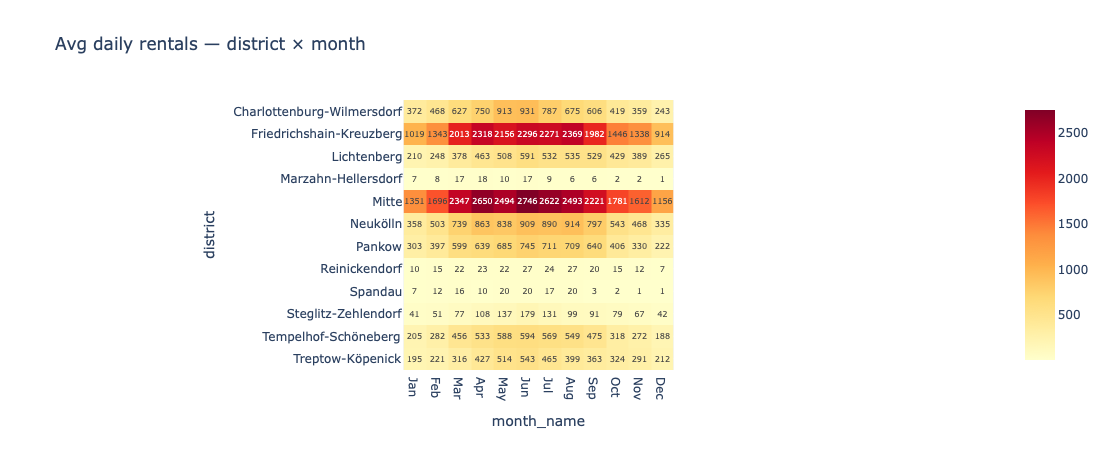

In [21]:
# Heatmap: district vs month average demand
pivot = month_avg.pivot(index='district', columns='month_name', values='rentals')
# Reorder months
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot = pivot[[m for m in month_order if m in pivot.columns]]

fig = px.imshow(
    pivot.round(0),
    text_auto=True,
    color_continuous_scale='YlOrRd',
    title='Avg daily rentals — district × month',
    height=450
)
fig.show()

## 6. Weather Data (Open-Meteo)

We fetch **hourly** historical weather for Berlin from the Open-Meteo archive API (free, no API key required), then aggregate to **daily** summaries to match our demand data.

The result is saved to `data/processed/weather_daily.parquet` so we only fetch once.

| Variable | Daily aggregation |
|---|---|
| temperature_2m | mean |
| apparent_temperature | mean |
| precipitation | sum |
| rain | sum |
| snowfall | sum |
| wind_speed_10m | mean |
| cloud_cover | mean |
| relative_humidity_2m | mean |
| weather_code | mode (most frequent code of the day) |

In [22]:
import requests_cache
import openmeteo_requests
from retry_requests import retry

WEATHER_PATH = PROCESSED_DIR / 'weather_daily.parquet'
ARCHIVE_URL = 'https://archive-api.open-meteo.com/v1/archive'
HOURLY_VARS = [
    'temperature_2m', 'precipitation', 'apparent_temperature',
    'rain', 'snowfall', 'weather_code', 'wind_speed_10m',
    'relative_humidity_2m', 'cloud_cover',
]

In [23]:
def fetch_hourly_weather(start_date: str, end_date: str) -> pd.DataFrame:
    cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    params = {
        'latitude': 52.52,
        'longitude': 13.41,
        'hourly': HOURLY_VARS,
        'start_date': start_date,
        'end_date': end_date,
    }
    response = openmeteo.weather_api(ARCHIVE_URL, params=params)[0]
    hourly = response.Hourly()

    data = {
        'timestamp': pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit='s', utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit='s', utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive='left',
        )
    }
    for i, var in enumerate(HOURLY_VARS):
        data[var] = hourly.Variables(i).ValuesAsNumpy()

    df = pd.DataFrame(data)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert(TIMEZONE)
    return df


def aggregate_to_daily(hourly_df: pd.DataFrame) -> pd.DataFrame:
    hourly_df['date'] = hourly_df['timestamp'].dt.date
    daily = hourly_df.groupby('date').agg(
        temperature_2m=('temperature_2m', 'mean'),
        apparent_temperature=('apparent_temperature', 'mean'),
        precipitation=('precipitation', 'sum'),
        rain=('rain', 'sum'),
        snowfall=('snowfall', 'sum'),
        wind_speed_10m=('wind_speed_10m', 'mean'),
        cloud_cover=('cloud_cover', 'mean'),
        relative_humidity_2m=('relative_humidity_2m', 'mean'),
        weather_code=('weather_code', lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    ).reset_index()
    daily['date'] = pd.to_datetime(daily['date'])
    return daily

In [24]:
# Fetch once, save to parquet — re-running this cell reloads from disk
if WEATHER_PATH.exists():
    weather_daily = pd.read_parquet(WEATHER_PATH)
    print(f'Loaded from cache: {WEATHER_PATH}')
else:
    print('Fetching weather from Open-Meteo archive...')
    hourly = fetch_hourly_weather(start_date='2025-01-01', end_date='2026-04-30')
    weather_daily = aggregate_to_daily(hourly)
    weather_daily.to_parquet(WEATHER_PATH, index=False)
    print(f'Saved to {WEATHER_PATH}')

print(f'\nShape: {weather_daily.shape}')
print(f'Date range: {weather_daily["date"].min().date()} → {weather_daily["date"].max().date()}')
weather_daily.head()

Loaded from cache: ../data/processed/weather_daily.parquet

Shape: (486, 10)
Date range: 2025-01-01 → 2026-05-01


,date,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,cloud_cover,relative_humidity_2m,weather_code
0,2025-01-01,4.97,-0.44,0.10,0.10,0.00,23.45,100.00,74.93,3.00
1,2025-01-02,4.03,-0.42,4.10,4.10,0.00,17.70,60.58,83.57,51.00
2,2025-01-03,0.78,-4.49,3.10,0.40,1.89,19.90,65.12,83.46,3.00
3,2025-01-04,-1.12,-5.48,0.00,0.00,0.00,12.32,59.88,86.25,3.00
4,2025-01-05,-1.03,-5.31,9.30,3.90,3.78,11.81,100.00,85.84,3.00


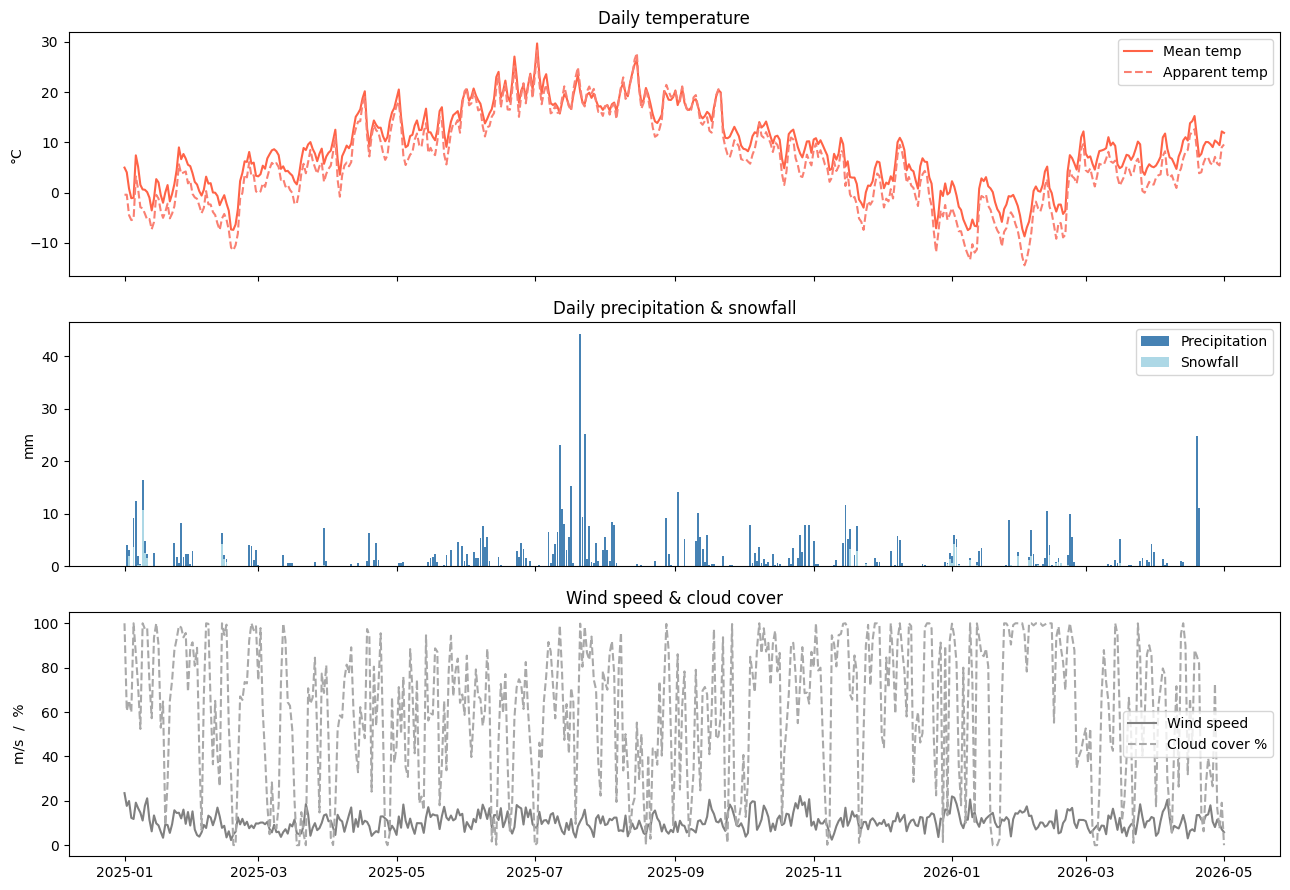

In [25]:
# Weather overview plots
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(weather_daily['date'], weather_daily['temperature_2m'], color='tomato', label='Mean temp')
axes[0].plot(weather_daily['date'], weather_daily['apparent_temperature'], color='salmon', linestyle='--', label='Apparent temp')
axes[0].set_ylabel('°C')
axes[0].set_title('Daily temperature')
axes[0].legend()

axes[1].bar(weather_daily['date'], weather_daily['precipitation'], color='steelblue', label='Precipitation')
axes[1].bar(weather_daily['date'], weather_daily['snowfall'], color='lightblue', label='Snowfall')
axes[1].set_ylabel('mm')
axes[1].set_title('Daily precipitation & snowfall')
axes[1].legend()

axes[2].plot(weather_daily['date'], weather_daily['wind_speed_10m'], color='grey', label='Wind speed')
axes[2].plot(weather_daily['date'], weather_daily['cloud_cover'], color='darkgrey', linestyle='--', label='Cloud cover %')
axes[2].set_ylabel('m/s  /  %')
axes[2].set_title('Wind speed & cloud cover')
axes[2].legend()

plt.tight_layout()
plt.show()

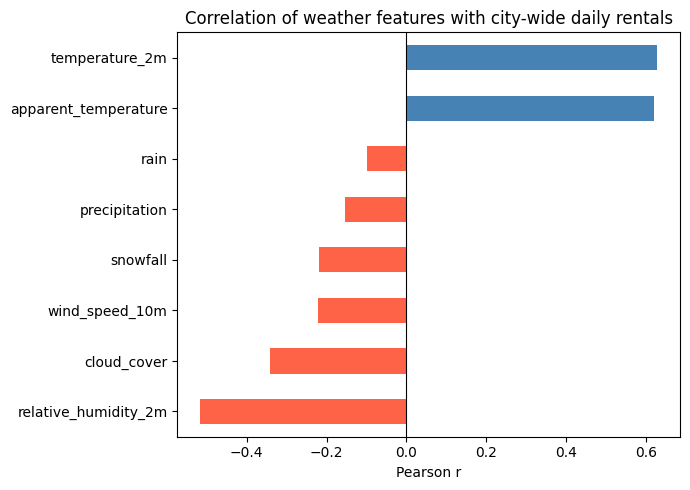

relative_humidity_2m   -0.52
cloud_cover            -0.34
wind_speed_10m         -0.22
snowfall               -0.22
precipitation          -0.15
rain                   -0.10
apparent_temperature    0.62
temperature_2m          0.63


In [26]:
# Correlation between weather and city-wide demand
city_total = district_daily.groupby('date')['rentals'].sum().reset_index().rename(columns={'rentals': 'total_rentals'})
weather_demand = city_total.merge(weather_daily, on='date', how='inner')

weather_cols = ['temperature_2m', 'apparent_temperature', 'precipitation',
                'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m']

corr = weather_demand[weather_cols + ['total_rentals']].corr()['total_rentals'].drop('total_rentals').sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
corr.plot(kind='barh', ax=ax, color=['tomato' if v < 0 else 'steelblue' for v in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of weather features with city-wide daily rentals')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

print(corr.to_string())

## 7. Feature Engineering Preview

The model will predict `rentals_tomorrow` for each district.  
We build features from five groups:

| Group | Features |
|-------|----------|
| **Temporal** | day-of-week, month, is_weekend, is_holiday, season |
| **Lag** | demand yesterday, 2d ago, 7d ago, 14d ago (per district) |
| **Rolling** | 3-day, 7-day, 14-day rolling mean demand (per district) |
| **Network** | active station count (per district) |
| **Weather** | temperature, apparent temperature, precipitation, rain, snowfall, wind, cloud cover, humidity |

In [27]:
# Build feature DataFrame for the busiest district
TARGET_DISTRICT = district_daily['district'].value_counts().index[0]
print(f'Showing feature preview for: {TARGET_DISTRICT}')

target_df = (
    district_daily[district_daily['district'] == TARGET_DISTRICT]
    .sort_values('date')
    .set_index('date')[['rentals']]
    .copy()
)

# German / Berlin holidays
de_holidays = holidays.Germany(state='BE', years=range(2025, 2027))

# Temporal features
target_df['dow'] = target_df.index.dayofweek
target_df['month'] = target_df.index.month
target_df['is_weekend'] = (target_df.index.dayofweek >= 5).astype(int)
target_df['is_holiday'] = target_df.index.map(lambda d: int(d in de_holidays))
target_df['season'] = target_df.index.month.map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
})

# Lag features
for lag in [1, 2, 7, 14]:
    target_df[f'lag_{lag}d'] = target_df['rentals'].shift(lag)

# Rolling features
for window in [3, 7, 14]:
    target_df[f'roll_{window}d_mean'] = target_df['rentals'].shift(1).rolling(window).mean()
    target_df[f'roll_{window}d_std'] = target_df['rentals'].shift(1).rolling(window).std()

# Weather features (today's weather predicts tomorrow's demand)
weather_cols = [
    'temperature_2m', 'apparent_temperature', 'precipitation',
    'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'relative_humidity_2m'
]
target_df = target_df.merge(
    weather_daily[['date'] + weather_cols].set_index('date'),
    left_index=True, right_index=True, how='left'
)

# Target = next day's demand
target_df['rentals_tomorrow'] = target_df['rentals'].shift(-1)

print(f'\nFeature set shape (raw): {target_df.shape}')
print(f'Valid rows (all features present): {target_df.dropna().shape[0]}')
target_df.tail(5)

Showing feature preview for: Charlottenburg-Wilmersdorf

Feature set shape (raw): (486, 25)
Valid rows (all features present): 471


,rentals,dow,month,is_weekend,is_holiday,season,lag_1d,lag_2d,lag_7d,lag_14d,roll_3d_mean,roll_3d_std,roll_7d_mean,roll_7d_std,roll_14d_mean,roll_14d_std,temperature_2m,apparent_temperature,precipitation,rain,snowfall,wind_speed_10m,cloud_cover,relative_humidity_2m,rentals_tomorrow
date,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-27,478.00,0,4,0,0,spring,358.00,362.00,275.00,359.00,387.67,47.96,434.71,106.13,439.21,107.72,10.37,7.11,0.00,0.00,0.00,8.17,72.83,46.58,615.00
2026-04-28,615.00,1,4,0,0,spring,478.00,358.00,525.00,480.00,399.33,68.16,463.71,79.65,447.71,105.58,9.97,5.77,0.00,0.00,0.00,11.47,16.62,35.66,617.00
2026-04-29,617.00,2,4,0,0,spring,615.00,478.00,556.00,551.00,483.67,128.59,476.57,96.64,457.36,114.54,9.43,5.41,0.00,0.00,0.00,9.63,7.50,36.27,628.00
2026-04-30,628.00,3,4,0,0,spring,617.00,615.00,524.00,552.00,570.00,79.68,485.29,107.17,462.07,119.92,12.16,9.01,0.00,0.00,0.00,7.16,19.12,41.58,4.00
2026-05-01,4.00,4,5,0,1,spring,628.00,617.00,443.00,494.00,620.00,7.00,500.14,119.89,467.50,125.88,11.88,9.57,0.00,0.00,0.00,5.83,0.00,57.96,NaN


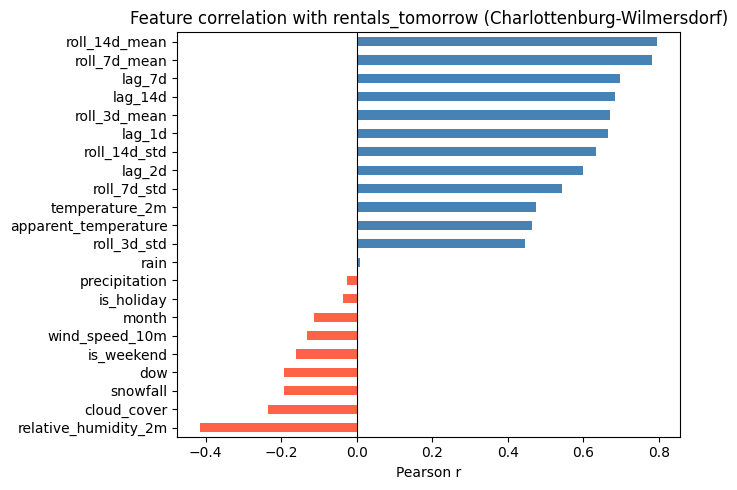

relative_humidity_2m   -0.41
cloud_cover            -0.24
snowfall               -0.19
dow                    -0.19
is_weekend             -0.16
wind_speed_10m         -0.13
month                  -0.11
is_holiday             -0.04
precipitation          -0.02
rain                    0.01
roll_3d_std             0.45
apparent_temperature    0.47
temperature_2m          0.47
roll_7d_std             0.54
lag_2d                  0.60
roll_14d_std            0.63
lag_1d                  0.66
roll_3d_mean            0.67
lag_14d                 0.68
lag_7d                  0.70
roll_7d_mean            0.78
roll_14d_mean           0.80


In [30]:
# Correlation of features with target
feat_cols = [c for c in target_df.columns if c not in ('rentals', 'rentals_tomorrow', 'season')]
corr = target_df[feat_cols + ['rentals_tomorrow']].dropna().corr()['rentals_tomorrow'].drop('rentals_tomorrow').sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
corr.plot(kind='barh', ax=ax, color=['tomato' if v < 0 else 'steelblue' for v in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Feature correlation with rentals_tomorrow ({TARGET_DISTRICT})')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

print(corr.to_string())

##TODO: try "hours of rain" or "max hourly precipitation" instead of 'precipitation', 'rain'

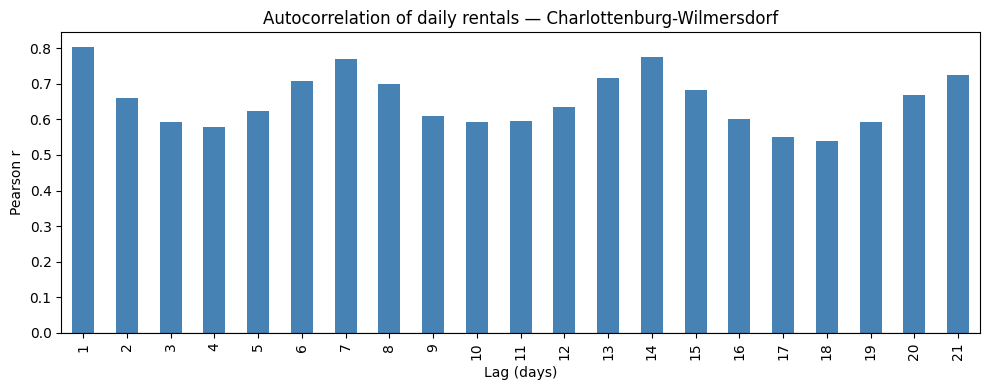

In [31]:
# Lag correlation: how many days back is most predictive?
max_lag = 21
lag_corrs = {}
for lag in range(1, max_lag + 1):
    lagged = target_df['rentals'].shift(lag)
    valid = target_df['rentals'].notna() & lagged.notna()
    lag_corrs[lag] = target_df['rentals'][valid].corr(lagged[valid])

lag_df = pd.Series(lag_corrs, name='correlation')

fig, ax = plt.subplots(figsize=(10, 4))
lag_df.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title(f'Autocorrelation of daily rentals — {TARGET_DISTRICT}')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Pearson r')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

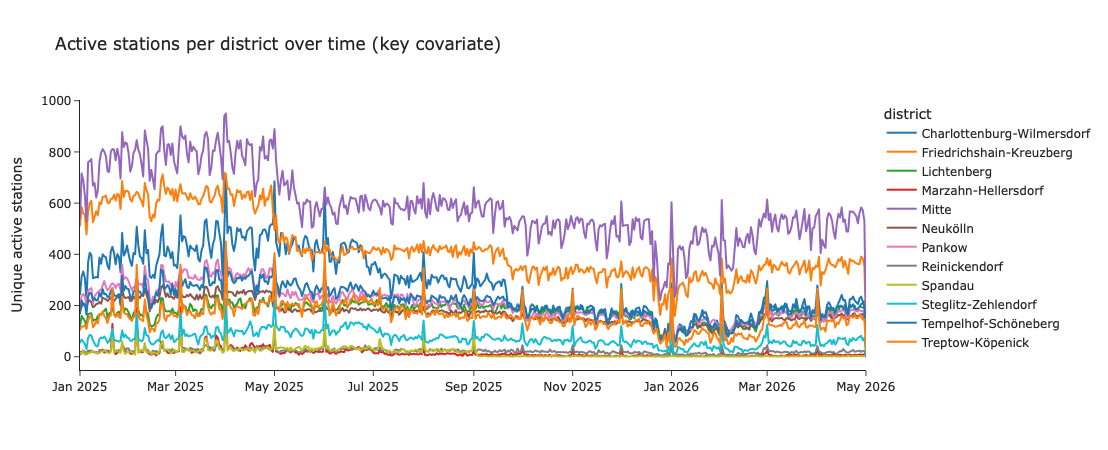

In [32]:
# Active station count per district per day — important covariate
# (captures network size changes that affect total demand)
active_stations = (
    demand_all.dropna(subset=['district'])
    .groupby(['date', 'district'])['nuid']
    .nunique()
    .reset_index()
    .rename(columns={'nuid': 'active_stations'})
)

fig = px.line(
    active_stations,
    x='date', y='active_stations', color='district',
    title='Active stations per district over time (key covariate)',
    labels={'active_stations': 'Unique active stations', 'date': ''},
    template='simple_white', height=450
)
fig.show()

## 8. Save Processed Data

In [33]:
# Save district-level daily demand (the base dataset for modelling)
out = district_daily[['date', 'district', 'rentals']].copy()
out = out.merge(active_stations, on=['date', 'district'], how='left')
out = out.sort_values(['district', 'date']).reset_index(drop=True)

out_path = PROCESSED_DIR / 'district_daily_demand.parquet'
out.to_parquet(out_path, index=False)
print(f'Saved {len(out):,} records to {out_path}')
print(out.head(10).to_string(index=False))

Saved 5,783 records to ../data/processed/district_daily_demand.parquet
      date                   district  rentals  active_stations
2025-01-01 Charlottenburg-Wilmersdorf   152.00              244
2025-01-02 Charlottenburg-Wilmersdorf   351.00              313
2025-01-03 Charlottenburg-Wilmersdorf   363.00              333
2025-01-04 Charlottenburg-Wilmersdorf   293.00              308
2025-01-05 Charlottenburg-Wilmersdorf   181.00              219
2025-01-06 Charlottenburg-Wilmersdorf   518.00              369
2025-01-07 Charlottenburg-Wilmersdorf   812.00              406
2025-01-08 Charlottenburg-Wilmersdorf   789.00              397
2025-01-09 Charlottenburg-Wilmersdorf   331.00              307
2025-01-10 Charlottenburg-Wilmersdorf   389.00              309
